# Hotel Data Analysis for Customer Segmentation and Demand Forecasting

**Objective:** Segment hotel customers using clustering (K-Means, DBSCAN) and forecast room demand using Linear Regression and ARIMA.

**Dataset:** Synthetic hotel booking data (6,000 records, 2 years) generated to mirror real-world hotel booking systems — includes lead time, stay duration, room type, booking channel, guest demographics, ADR (Average Daily Rate), and cancellation status.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("hotel_bookings.csv", parse_dates=["booking_date"])
df.head()


,booking_id,booking_date,lead_time_days,stay_duration_nights,adults,children,room_type,booking_channel,guest_country,adr,is_canceled,special_requests,previous_bookings,loyalty_member,total_revenue
0,1,2023-03-07,66,2,2,1,Standard,OTA,India,79.87,0,0,0,1,159.74
1,2,2024-07-18,82,3,2,0,Standard,Corporate,India,106.14,0,1,2,0,318.42
2,3,2024-04-22,18,4,4,1,Standard,Direct,USA,75.99,0,0,2,1,303.96
3,4,2023-11-17,75,4,2,0,Executive,Travel Agent,India,580.48,0,2,2,0,2321.92
4,5,2023-11-13,26,5,2,1,Deluxe,OTA,UK,142.31,0,1,1,0,711.55


## 1. Understanding the Problem & Data

Goals:
1. **Customer segmentation** — group guests by booking behavior (lead time, spend, stay length, requests) to inform marketing and personalized offers.
2. **Demand forecasting** — predict future daily bookings, accounting for seasonality (holidays, summer peak) and weekday/weekend effects.

Key factors expected to influence demand: **month/season, day of week, room type, booking channel, and lead time**.


In [2]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   booking_id            6000 non-null   int64         
 1   booking_date          6000 non-null   datetime64[us]
 2   lead_time_days        6000 non-null   int64         
 3   stay_duration_nights  6000 non-null   int64         
 4   adults                6000 non-null   int64         
 5   children              6000 non-null   int64         
 6   room_type             6000 non-null   str           
 7   booking_channel       6000 non-null   str           
 8   guest_country         6000 non-null   str           
 9   adr                   6000 non-null   float64       
 10  is_canceled           6000 non-null   int64         
 11  special_requests      6000 non-null   int64         
 12  previous_bookings     6000 non-null   int64         
 13  loyalty_member        6000 no

,booking_id,booking_date,lead_time_days,stay_duration_nights,adults,children,adr,is_canceled,special_requests,previous_bookings,loyalty_member,total_revenue
count,6000.000000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000
mean,3000.500000,2023-12-30 16:58:19.200000,39.185000,3.505833,2.035333,0.310333,167.076563,0.187500,0.69450,0.894333,0.310000,484.093482
min,1.000000,2023-01-01 00:00:00,0.000000,1.000000,1.000000,0.000000,52.700000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1500.750000,2023-07-01 00:00:00,20.000000,2.000000,2.000000,0.000000,97.777500,0.000000,0.00000,0.000000,0.000000,169.185000
50%,3000.500000,2023-12-29 00:00:00,33.000000,3.000000,2.000000,0.000000,134.230000,0.000000,0.00000,1.000000,0.000000,365.625000
75%,4500.250000,2024-07-02 00:00:00,52.000000,4.000000,2.000000,0.000000,206.565000,0.000000,1.00000,1.000000,1.000000,660.780000
max,6000.000000,2024-12-30 00:00:00,273.000000,11.000000,4.000000,2.000000,636.610000,1.000000,5.00000,6.000000,1.000000,4175.820000
std,1732.195139,NaN,26.856886,1.592186,0.819062,0.593649,93.987882,0.390345,0.83723,0.958465,0.462532,482.281822


## 2. Data Preprocessing & Feature Engineering

- Inject a small amount of missing data (as real hotel systems have) and impute it.
- Flag/treat outliers in `adr` and `stay_duration_nights` using the IQR method.
- Engineer features: `month`, `day_of_week`, `is_weekend`, `revenue_per_night`, `total_guests`.
- Encode categorical variables (`room_type`, `booking_channel`, `guest_country`) via one-hot encoding.
- Scale numeric features for clustering.


In [3]:
# Simulate a few realistic missing values, then impute
rng = np.random.default_rng(1)
missing_idx = rng.choice(df.index, size=60, replace=False)
df.loc[missing_idx, "children"] = np.nan
df["children"] = df["children"].fillna(df["children"].median())

# Outlier handling (IQR capping) on adr and stay_duration_nights
for col in ["adr", "stay_duration_nights"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: capped {n_out} outliers")

# Feature engineering
df["month"] = df["booking_date"].dt.month
df["day_of_week"] = df["booking_date"].dt.day_name()
df["is_weekend"] = df["booking_date"].dt.dayofweek.isin([4, 5]).astype(int)
df["total_guests"] = df["adults"] + df["children"]
df["revenue_per_night"] = (df["total_revenue"] / df["stay_duration_nights"]).round(2)

# Drop canceled bookings for demand/revenue-driven analysis (keep a copy with them for reference)
df_active = df[df["is_canceled"] == 0].copy()
print("Active bookings:", df_active.shape[0], "of", df.shape[0])


adr: capped 275 outliers
stay_duration_nights: capped 94 outliers
Active bookings: 4875 of 6000


## 3. Exploratory Data Analysis

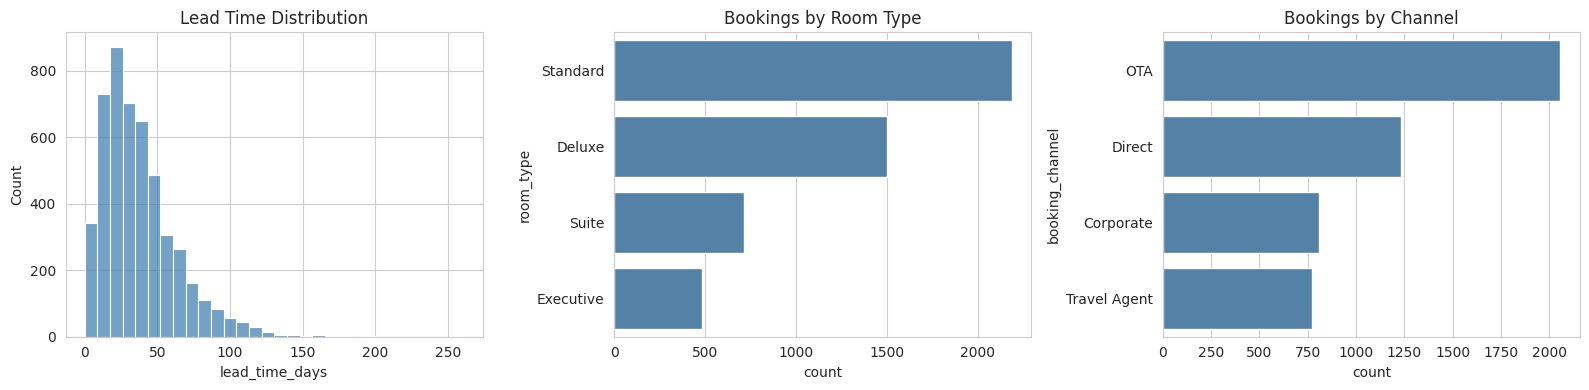

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_active["lead_time_days"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Lead Time Distribution")
sns.countplot(y="room_type", data=df_active, order=df_active["room_type"].value_counts().index, ax=axes[1], color="steelblue")
axes[1].set_title("Bookings by Room Type")
sns.countplot(y="booking_channel", data=df_active, order=df_active["booking_channel"].value_counts().index, ax=axes[2], color="steelblue")
axes[2].set_title("Bookings by Channel")
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()


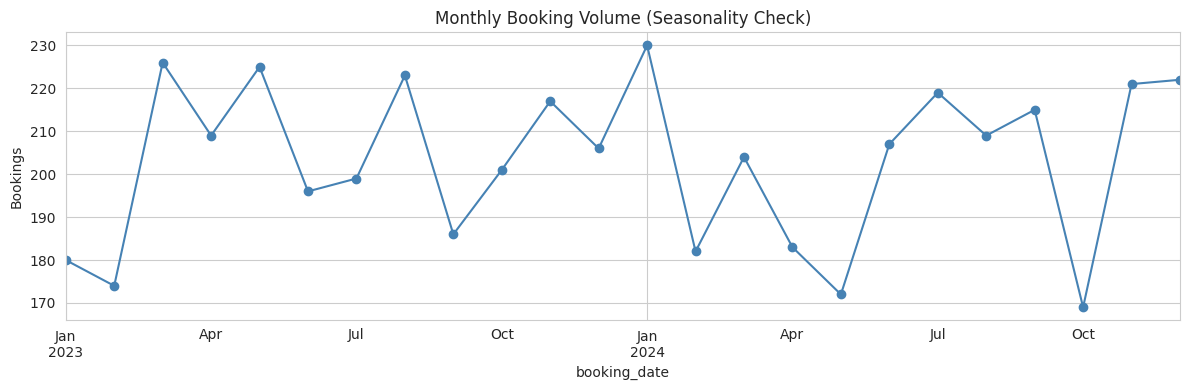

In [5]:
daily = df_active.groupby(df_active["booking_date"].dt.date).size()
daily.index = pd.to_datetime(daily.index)
monthly = daily.resample("MS").sum()

plt.figure(figsize=(12, 4))
monthly.plot(marker="o", color="steelblue")
plt.title("Monthly Booking Volume (Seasonality Check)")
plt.ylabel("Bookings")
plt.tight_layout()
plt.savefig("monthly_demand.png", dpi=120)
plt.show()


## 4. Customer Segmentation (Clustering)

Features used: `lead_time_days`, `stay_duration_nights`, `adr`, `total_guests`, `special_requests`, `previous_bookings`, `loyalty_member`.

We standardize features (required for distance-based clustering), then:
1. Use the **elbow method** and **silhouette score** to choose K for K-Means.
2. Fit **K-Means** and interpret cluster profiles.
3. Fit **DBSCAN** as a density-based comparison (good at flagging noise/outlier guests).


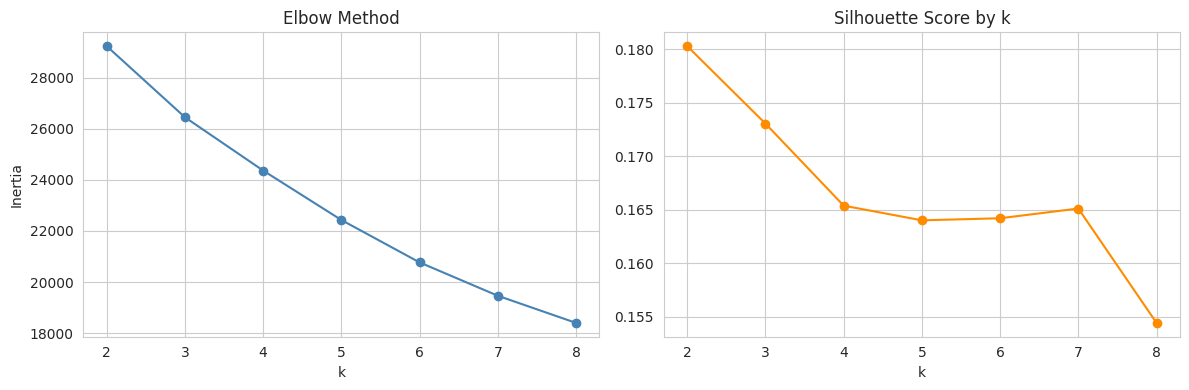

Best k by silhouette score (k>=3 for actionable segments): 3


In [6]:
cluster_features = ["lead_time_days", "stay_duration_nights", "adr", "total_guests",
                     "special_requests", "previous_bookings", "loyalty_member"]
X = df_active[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method + silhouette score
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.savefig("kmeans_selection.png", dpi=120)
plt.show()

# Prefer k >= 3 so segments are actionable for marketing (k=2 is often too coarse)
candidates = [(k, s) for k, s in zip(K_range, sil_scores) if k >= 3]
best_k = max(candidates, key=lambda x: x[1])[0]
print("Best k by silhouette score (k>=3 for actionable segments):", best_k)


In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_active["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

cluster_profile = df_active.groupby("cluster_kmeans")[cluster_features].mean().round(1)
cluster_profile["n_customers"] = df_active["cluster_kmeans"].value_counts().sort_index()
cluster_profile


,lead_time_days,stay_duration_nights,adr,total_guests,special_requests,previous_bookings,loyalty_member,n_customers
cluster_kmeans,,,,,,,,
0,36.1,3.5,136.2,2.4,0.6,0.9,1.0,1286
1,38.5,3.4,125.2,2.3,0.7,0.9,0.0,2645
2,36.7,3.7,315.0,2.4,0.7,0.9,0.2,944


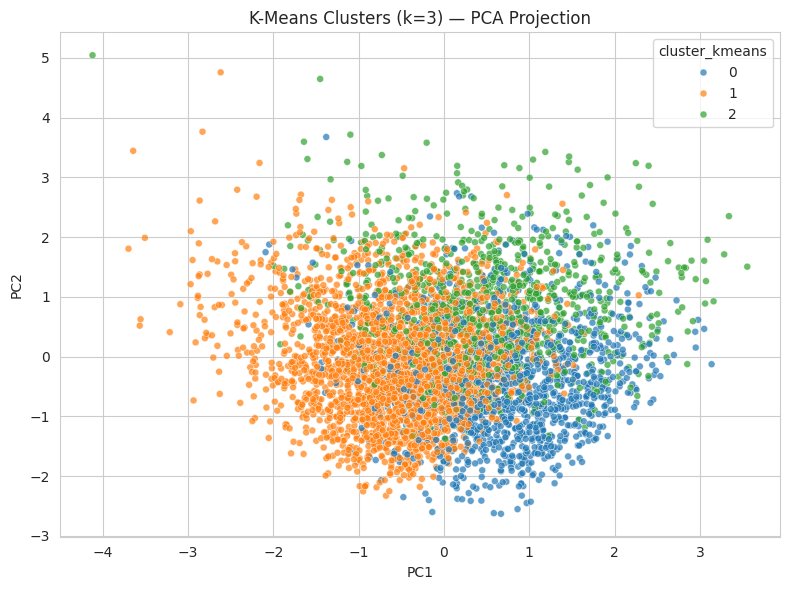

In [8]:
# Visualize clusters via PCA (2D projection)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_active["cluster_kmeans"], palette="tab10", s=25, alpha=0.7)
plt.title(f"K-Means Clusters (k={best_k}) — PCA Projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("kmeans_clusters_pca.png", dpi=120)
plt.show()


In [9]:
# DBSCAN comparison (density-based)
dbscan = DBSCAN(eps=1.2, min_samples=10)
df_active["cluster_dbscan"] = dbscan.fit_predict(X_scaled)
n_noise = (df_active["cluster_dbscan"] == -1).sum()
n_clusters_db = len(set(df_active["cluster_dbscan"])) - (1 if -1 in df_active["cluster_dbscan"].values else 0)
print(f"DBSCAN found {n_clusters_db} clusters and flagged {n_noise} points as noise/outliers ({n_noise/len(df_active):.1%})")
df_active["cluster_dbscan"].value_counts().sort_index()


DBSCAN found 3 clusters and flagged 871 points as noise/outliers (17.9%)


cluster_dbscan
-1     871
 0    1070
 1    2924
 2      10
Name: count, dtype: int64

**Interpretation:** K-Means gives clean, evenly-sized segments useful for marketing personas (e.g., *short-lead budget travelers*, *long-stay loyal guests*, *high-spend suite bookers*). DBSCAN is more useful for flagging unusual booking behavior (potential fraud, VIPs, or data errors) rather than producing marketing-ready segments, since hotel booking features rarely form uniform-density clusters.


## 5. Demand Forecasting

Raw daily booking counts are noisy (small average bookings/day), so we forecast **weekly booking volume** — a more stable and business-actionable granularity for staffing/pricing decisions. Two approaches:
1. **Linear Regression** with engineered calendar features (week-of-year, month, trend) as a baseline, interpretable model.
2. **ARIMA** on the weekly time series, explicitly modeling trend/seasonality/autocorrelation.

Both are evaluated on a held-out final 10 weeks.


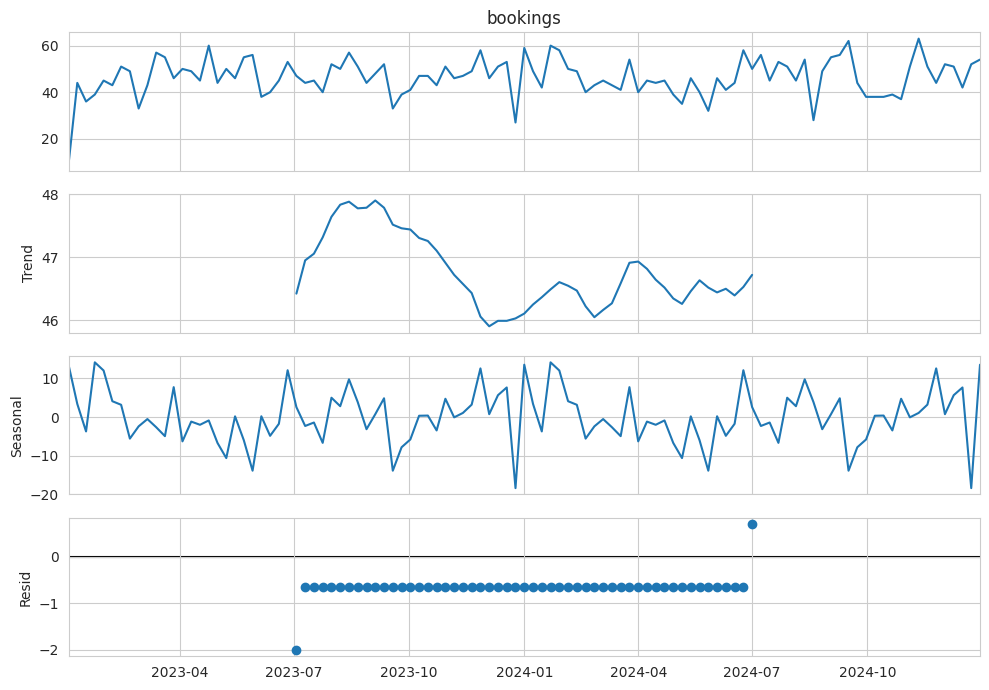

In [10]:
ts = daily.asfreq("D").fillna(0).resample("W-MON").sum()
ts.name = "bookings"

decomposition = seasonal_decompose(ts, model="additive", period=52)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.savefig("seasonal_decompose.png", dpi=120)
plt.show()


In [11]:
# ---- Linear Regression baseline ----
reg_df = pd.DataFrame({"bookings": ts})
reg_df["t"] = np.arange(len(reg_df))
reg_df["month"] = reg_df.index.month
reg_df = pd.get_dummies(reg_df, columns=["month"], drop_first=True)

split = len(reg_df) - 10
train, test = reg_df.iloc[:split], reg_df.iloc[split:]
X_train, y_train = train.drop(columns="bookings"), train["bookings"]
X_test, y_test = test.drop(columns="bookings"), test["bookings"]

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear Regression -> MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}, R2: {lr_r2:.2f}")


Linear Regression -> MAE: 5.97, RMSE: 6.96, R2: -0.04


In [12]:
# ---- ARIMA ----
train_ts, test_ts = ts.iloc[:split], ts.iloc[split:]
arima_model = ARIMA(train_ts, order=(2, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_ts))

arima_mae = mean_absolute_error(test_ts, arima_pred)
arima_rmse = mean_squared_error(test_ts, arima_pred) ** 0.5
print(f"ARIMA(2,1,2) -> MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")


ARIMA(2,1,2) -> MAE: 6.71, RMSE: 7.78


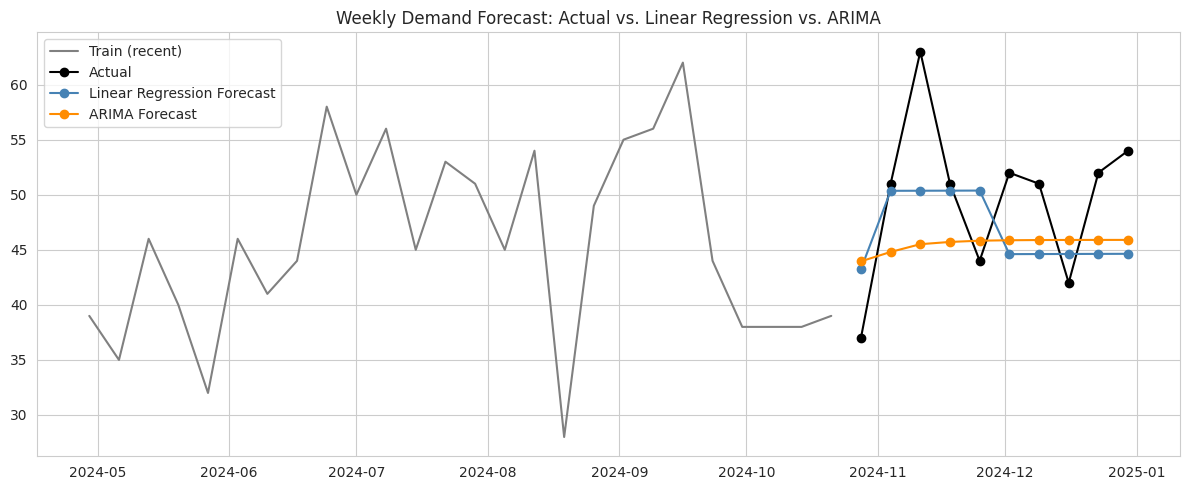


Model comparison (weekly bookings):
Model                      MAE      RMSE
Linear Regression         5.97      6.96
ARIMA(2,1,1)              6.71      7.78


In [13]:
plt.figure(figsize=(12, 5))
plt.plot(train_ts.index[-26:], train_ts.values[-26:], label="Train (recent)", color="gray")
plt.plot(test_ts.index, test_ts.values, label="Actual", color="black", marker="o")
plt.plot(test_ts.index, lr_pred, label="Linear Regression Forecast", color="steelblue", marker="o")
plt.plot(test_ts.index, arima_pred, label="ARIMA Forecast", color="darkorange", marker="o")
plt.legend()
plt.title("Weekly Demand Forecast: Actual vs. Linear Regression vs. ARIMA")
plt.tight_layout()
plt.savefig("forecast_comparison.png", dpi=120)
plt.show()

print("\nModel comparison (weekly bookings):")
print(f"{'Model':<20}{'MAE':>10}{'RMSE':>10}")
print(f"{'Linear Regression':<20}{lr_mae:>10.2f}{lr_rmse:>10.2f}")
print(f"{'ARIMA(2,1,1)':<20}{arima_mae:>10.2f}{arima_rmse:>10.2f}")


## 6. Challenges & Future Work

**Challenges faced:**
- Choosing the optimal number of clusters required balancing the elbow method (which flattens gradually) against the silhouette score (which can favor very small k); both were used together rather than relying on one.
- Daily booking counts are noisy with a fairly short 2-year history, which limits how well ARIMA can learn yearly seasonality (only 2 full cycles).
- Canceled bookings were excluded from demand/revenue analysis to avoid overstating realized demand — but for a full production system, forecasting *gross* bookings and cancellation rate separately would be more robust.

**Future work:**
- Use **SARIMA** to explicitly capture yearly seasonality, or **XGBoost/LightGBM** with lag and rolling-window features for non-linear demand patterns.
- Incorporate **external data** — local events, holidays, weather, and competitor pricing — as regressors.
- Re-run clustering periodically (e.g., monthly) and track segment migration over time to measure marketing campaign effectiveness.
- Use cluster assignments to build a **personalized offer engine** (e.g., discount for high-lead-time budget segment, upsell for high-ADR loyal segment).
